# ICTER 2026 V2X Anomaly Detection Pipeline  
## Vehicle-wise Reconstruction-based Temporal Anomaly Detection using LSTM-AE, GRU-AE and CNN-AE

This notebook provides a clean, modular, ICTER-ready experimental pipeline for V2X anomaly detection using the VeReMi Extension dataset.

Main design choices:
- shared preprocessing for all models
- vehicle-wise temporal split to avoid leakage
- reusable sequence generation
- unsupervised training using normal sequences only
- reconstruction-error based anomaly scoring
- unified threshold sensitivity evaluation
- export-ready tables and figures

In [1]:
import os
from google.colab import drive


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shilpasayura","key":"7fea73bd3287dec6040362682df60c80"}'}

In [ ]:

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

 1. ENVIRONMENT SETUP

In [2]:
# =========================================================
# 1. ENVIRONMENT SETUP
# =========================================================

import os
import gc
import time
import json
import random
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, precision_recall_curve,
    roc_curve, auc, classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU Available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU Available: False


 2. CONFIGURATION

In [3]:
# =========================================================
# 2. CONFIGURATION
# =========================================================

CONFIG = {
    # Dataset path after Kaggle extraction.
    # Update this path if your CSV is stored in Google Drive.
    "file_path": "/content/veremi-extension-final/mixalldata_clean.csv",

    # Sequence setup
    "seq_len": 10,
    "label_mode": "any",      # "any" means a sequence is attack if any timestep is attack

    # Split setup
    "test_size": 0.20,
    "val_size": 0.20,
    "random_state": 42,

    # Sampling setup
    "use_sampling": True,
    "total_target": 120000,
    "normal_target": 20000,

    # Training setup
    "epochs": 100,
    "batch_size": 128,
    "learning_rate": 1e-3,

    # Threshold setup
    "threshold_percentiles": [80, 85, 90, 95, 97],
    "selected_percentile": 85,

    # Output folders
    "output_dir": "/content/output",
    "figure_dir": "/content/output/figures",
    "table_dir": "/content/output/tables",
    "model_dir": "/content/output/models"
}

for d in [CONFIG["output_dir"], CONFIG["figure_dir"], CONFIG["table_dir"], CONFIG["model_dir"]]:
    os.makedirs(d, exist_ok=True)

RAW_FEATURES = [
    "posx", "posy", "posz",
    "spdx", "spdy", "spdz",
    "aclx", "acly", "aclz",
    "hedx", "hedy", "hedz"
]

ID_COLS = ["sendTime", "sender", "senderPseudo", "messageID", "class"]
GROUP_COL = "senderPseudo"
TIME_COL = "sendTime"
CLASS_COL = "class"
LABEL_COL = "binary_label"
WINDOW_SIZE=10
print(json.dumps(CONFIG, indent=2))

{
  "file_path": "/content/veremi-extension-final/mixalldata_clean.csv",
  "seq_len": 10,
  "label_mode": "any",
  "test_size": 0.2,
  "val_size": 0.2,
  "random_state": 42,
  "use_sampling": true,
  "total_target": 120000,
  "normal_target": 20000,
  "epochs": 100,
  "batch_size": 128,
  "learning_rate": 0.001,
  "threshold_percentiles": [
    80,
    85,
    90,
    95
  ],
  "selected_percentile": 85,
  "output_dir": "/content/output",
  "figure_dir": "/content/output/figures",
  "table_dir": "/content/output/tables",
  "model_dir": "/content/output/models"
}


3. Download Veremi Extention dataset

In [ ]:
!kaggle datasets download -d cyberdeeplearning/veremi-extension-clean-data

import zipfile
with zipfile.ZipFile("veremi-extension-clean-data.zip", 'r') as zip_ref:
    zip_ref.extractall("veremi-extension-final")

import os
os.listdir("veremi-extension-final")

Dataset URL: https://www.kaggle.com/datasets/cyberdeeplearning/veremi-extension-clean-data
License(s): unknown
100% 405M/405M [00:03<00:00, 129MB/s]



['mixalldata_clean.csv']

4. DATA LOADING

In [4]:
# =========================================================
# 4. DATA LOADING
# =========================================================

def load_veremi_data(file_path, usecols=None):
    """Load VeReMi Extension CSV with selected columns."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Dataset not found: {file_path}\n"
            "Update CONFIG['file_path'] or run the Kaggle download section."
        )

    df_raw = pd.read_csv(file_path, usecols=usecols)
    print("Loaded dataset:",df_raw.shape)
    return df_raw


usecols = ID_COLS + RAW_FEATURES

df = load_veremi_data(CONFIG["file_path"], usecols=usecols)
display(df.head())
print(df.info())

Loaded dataset: (3194808, 17)


,sendTime,sender,senderPseudo,messageID,class,posx,posy,posz,spdx,spdy,spdz,aclx,acly,aclz,hedx,hedy,hedz
0,72002.302942,130137,101301377,422013806,0,266.982401,32.336955,0.0,-0.124661,1.206343,0.0,-0.219100,2.120328,0.0,-0.102790,0.994703,0.0
1,72003.302942,130137,101301377,422023410,0,266.827208,34.624145,0.0,-0.323739,3.132858,0.0,-0.216966,2.099684,0.0,-0.099856,0.995002,0.0
2,72004.302942,130137,101301377,422032081,0,266.420297,38.836461,0.0,-0.522008,5.051538,0.0,-0.184437,1.784944,0.0,-0.099856,0.995002,0.0
3,72005.302942,130137,101301377,422040712,0,268.912026,45.414229,0.0,-0.746193,7.198828,0.0,-0.187751,1.811453,0.0,-0.100172,0.994970,0.0
4,72006.302942,130137,101301377,422052949,0,268.242276,53.729986,0.0,-0.961819,9.279121,0.0,-0.258225,2.491295,0.0,-0.097105,0.995274,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3194808 entries, 0 to 3194807
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   sendTime      float64
 1   sender        int64  
 2   senderPseudo  int64  
 3   messageID     int64  
 4   class         int64  
 5   posx          float64
 6   posy          float64
 7   posz          float64
 8   spdx          float64
 9   spdy          float64
 10  spdz          float64
 11  aclx          float64
 12  acly          float64
 13  aclz          float64
 14  hedx          float64
 15  hedy          float64
 16  hedz          float64
dtypes: float64(13), int64(4)
memory usage: 414.4 MB
None


5. PREPROCESSING AND FEATURE ENGINEERING

In [5]:
# =========================================================
# TEMPORAL SEQUENCE GENERATION
# =========================================================

X_seq = []
y_seq = []

seq_groups = []
seq_times = []
seq_classes = []

for group_id, group_df in df.groupby(GROUP_COL):

    group_df = group_df.sort_values(TIME_COL)

    features = group_df[RAW_FEATURES].values

    labels = (
        group_df[CLASS_COL] != 0
    ).astype(int).values

    classes = group_df[CLASS_COL].values

    times = group_df[TIME_COL].values

    if len(group_df) < WINDOW_SIZE:
        continue

    for i in range(len(group_df) - WINDOW_SIZE + 1):

        X_seq.append(
            features[i:i + WINDOW_SIZE]
        )

        y_seq.append(
            int(np.max(labels[i:i + WINDOW_SIZE]))
        )

        seq_groups.append(group_id)

        seq_times.append(
            times[i + WINDOW_SIZE - 1]
        )

        seq_classes.append(
            int(np.max(classes[i:i + WINDOW_SIZE]))
        )

X_seq = np.array(X_seq, dtype=np.float32)

y_seq = np.array(y_seq, dtype=np.int32)

seq_groups = np.array(seq_groups)

seq_times = np.array(seq_times)

seq_classes = np.array(seq_classes)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)

X_seq: (2762306, 10, 12)
y_seq: (2762306,)


In [6]:
# =========================================================
# TEMPORAL SAMPLING + SPLITTING
# Total = 120,000 sequences
# Train = 20,000 normal only
# Val   = 10,000 normal only
# Test  = 90,000 mixed normal + attack
# =========================================================

import numpy as np
import pandas as pd

TOTAL_TARGET = 120000
TRAIN_NORMAL = 20000
VAL_NORMAL = 10000
TEST_NORMAL = 45000
TEST_ATTACK = 45000

# -----------------------------
# Separate normal and attack
# -----------------------------
normal_mask = (y_seq == 0)
attack_mask = (y_seq == 1)

X_normal = X_seq[normal_mask]
y_normal = y_seq[normal_mask]
groups_normal = seq_groups[normal_mask]
times_normal = seq_times[normal_mask]
classes_normal = seq_classes[normal_mask]

X_attack = X_seq[attack_mask]
y_attack = y_seq[attack_mask]
groups_attack = seq_groups[attack_mask]
times_attack = seq_times[attack_mask]
classes_attack = seq_classes[attack_mask]

print("Available normal:", X_normal.shape)
print("Available attack:", X_attack.shape)

# -----------------------------
# Normal-only train and val
# -----------------------------
X_train = X_normal[:TRAIN_NORMAL]
y_train = y_normal[:TRAIN_NORMAL]

X_val = X_normal[TRAIN_NORMAL:TRAIN_NORMAL + VAL_NORMAL]
y_val = y_normal[TRAIN_NORMAL:TRAIN_NORMAL + VAL_NORMAL]

# -----------------------------
# Normal test sample
# -----------------------------
normal_test_start = TRAIN_NORMAL + VAL_NORMAL
normal_test_end = normal_test_start + TEST_NORMAL

X_test_normal = X_normal[normal_test_start:normal_test_end]
y_test_normal = y_normal[normal_test_start:normal_test_end]
groups_test_normal = groups_normal[normal_test_start:normal_test_end]
times_test_normal = times_normal[normal_test_start:normal_test_end]
classes_test_normal = classes_normal[normal_test_start:normal_test_end]

# -----------------------------
# Attack test sample
# -----------------------------
X_test_attack = X_attack[:TEST_ATTACK]
y_test_attack = y_attack[:TEST_ATTACK]
groups_test_attack = groups_attack[:TEST_ATTACK]
times_test_attack = times_attack[:TEST_ATTACK]
classes_test_attack = classes_attack[:TEST_ATTACK]

# -----------------------------
# Mixed test set
# -----------------------------
X_test = np.concatenate([X_test_normal, X_test_attack], axis=0)
y_test = np.concatenate([y_test_normal, y_test_attack], axis=0)

test_groups = np.concatenate([groups_test_normal, groups_test_attack], axis=0)
test_times = np.concatenate([times_test_normal, times_test_attack], axis=0)
test_classes = np.concatenate([classes_test_normal, classes_test_attack], axis=0)

# Sort test by time
sort_idx = np.argsort(test_times)

X_test = X_test[sort_idx]
y_test = y_test[sort_idx]
test_groups = test_groups[sort_idx]
test_times = test_times[sort_idx]
test_classes = test_classes[sort_idx]

# -----------------------------
# Summary
# -----------------------------
total_sequences = len(X_train) + len(X_val) + len(X_test)

print("\nFinal Split Summary")
print("-------------------")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train:")
print(pd.Series(y_train).value_counts().sort_index())

print("\ny_val:")
print(pd.Series(y_val).value_counts().sort_index())

print("\ny_test:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nTotal sequences:", total_sequences)

Available normal: (1746297, 10, 12)
Available attack: (1016009, 10, 12)

Final Split Summary
-------------------
X_train: (20000, 10, 12)
X_val:   (10000, 10, 12)
X_test:  (90000, 10, 12)

y_train:
0    20000
Name: count, dtype: int64

y_val:
0    10000
Name: count, dtype: int64

y_test:
0    45000
1    45000
Name: count, dtype: int64

Total sequences: 120000


The original VeReMi Extension dataset contained approximately 3.19 million V2X communication records. Vehicle-wise temporal windows of length 10 were generated by grouping records according to pseudonymous vehicle identity and transmission time, preserving behavioural continuity within each communication stream. Each sequence label was assigned using the final timestep of the window.

Since reconstruction-based autoencoders are designed to learn normal behavioural patterns, only benign sequences were used during training and validation. The final experimental subset consisted of 120,000 temporal sequences, partitioned into 20,000 normal training sequences, 10,000 normal validation sequences, and a balanced mixed test set containing 45,000 normal and 45,000 attack sequences.

Random shuffling was disabled during dataset partitioning and model training to preserve temporal ordering and sequential behavioural dependencies within V2X communication streams. This strategy enabled stable recurrent learning while maintaining computational feasibility for comparative evaluation of LSTM-AE, GRU-AE, and CNN-AE models.


Times New Roman style applied.


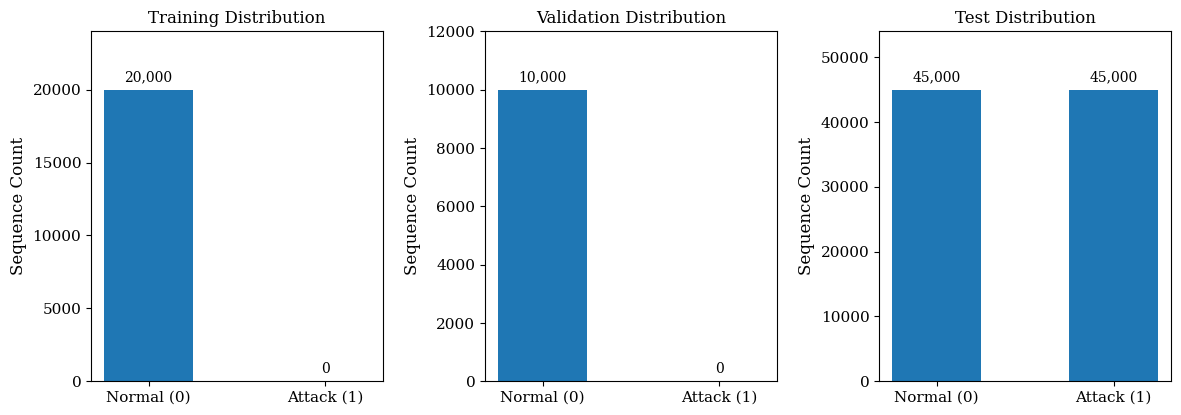

Saved: train_val_test_distribution.png


In [7]:
# =========================================================
# TRAIN / VALIDATION / TEST DISTRIBUTION PLOTS
# FIXED LABEL SPACING
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd
# =========================================================
# GLOBAL PLOT STYLE
# TIMES NEW ROMAN
# =========================================================


plt.rcParams["font.family"] = "serif"

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

plt.rcParams["legend.fontsize"] = 11

plt.rcParams["figure.titlesize"] = 14

print("Times New Roman style applied.")
# -----------------------------
# Create distributions
# -----------------------------
train_dist = pd.Series(y_train).value_counts().sort_index()
val_dist = pd.Series(y_val).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

# Ensure both classes exist
for cls in [0, 1]:
    if cls not in train_dist:
        train_dist[cls] = 0
    if cls not in val_dist:
        val_dist[cls] = 0
    if cls not in test_dist:
        test_dist[cls] = 0

train_dist = train_dist.sort_index()
val_dist = val_dist.sort_index()
test_dist = test_dist.sort_index()

labels = ["Normal (0)", "Attack (1)"]

# =========================================================
# Figure
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

plot_data = [
    ("Training Distribution", train_dist),
    ("Validation Distribution", val_dist),
    ("Test Distribution", test_dist)
]

for ax, (title, dist) in zip(axes, plot_data):

    bars = ax.bar(labels, dist.values, width=0.5)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Sequence Count")

    # Add top margin so labels don't touch border
    max_val = max(dist.values)
    ax.set_ylim(0, max_val * 1.20)

    # Value labels
    for i, v in enumerate(dist.values):
        ax.text(
            i,
            v + max_val * 0.03,
            f"{v:,}",
            ha='center',
            fontsize=10
        )

# =========================================================
# Outer spacing
# =========================================================
plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.85,
    bottom=0.15,
    wspace=0.35
)

# Save
save_path = "train_val_test_distribution.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.5
)

plt.show()

print("Saved:", save_path)

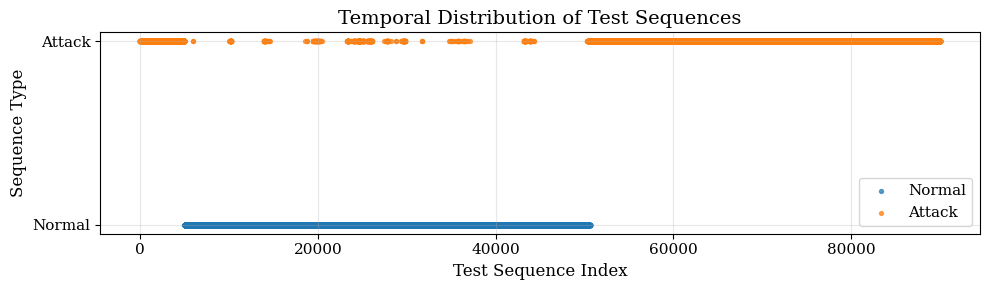

Saved: temporal_test_distribution.png


In [8]:
# =========================================================
# TEMPORAL TEST SEQUENCE DISTRIBUTION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Sequence indices
# ---------------------------------------------------------
sequence_idx = np.arange(len(y_test))

# Masks
normal_mask = (y_test == 0)
attack_mask = (y_test == 1)

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(10, 3))

# Normal sequences
plt.scatter(
    sequence_idx[normal_mask],
    y_test[normal_mask],
    s=8,
    label="Normal",
    alpha=0.7
)

# Attack sequences
plt.scatter(
    sequence_idx[attack_mask],
    y_test[attack_mask],
    s=8,
    label="Attack",
    alpha=0.7
)

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------
plt.yticks([0, 1], ["Normal", "Attack"])

plt.xlabel("Test Sequence Index")
plt.ylabel("Sequence Type")

plt.title("Temporal Distribution of Test Sequences")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

# Save
save_path = "temporal_test_distribution.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3
)

plt.show()

print("Saved:", save_path)

This figure shows the temporal distribution of the final test dataset used for anomaly detection evaluation. Each point represents one vehicle-wise temporal sequence. The x-axis indicates the ordered sequence index, while the y-axis distinguishes normal and attack sequences.

Normal sequences appear in the earlier portion of the test stream, while attack sequences occur intermittently and become more concentrated in later regions. The distribution confirms that temporal ordering was preserved without random shuffling, allowing the autoencoder models to evaluate sequential behavioural patterns under realistic V2X communication conditions.

In [15]:
# =========================================================
# SAFE SCALE + SAVE CELL
# =========================================================

import os
import json
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler

SAVE_DIR = "/content/output"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# FIT SCALER ONLY ON TRAIN DATA
# =========================================================

scaler = StandardScaler()

X_train_flat = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_flat)

def scale_3d(X, scaler):
    original_shape = X.shape
    X_flat = X.reshape(-1, original_shape[-1])
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(original_shape).astype(np.float32)

# =========================================================
# TRANSFORM AFTER SPLIT
# =========================================================

X_train_scaled = scale_3d(X_train, scaler)
X_val_scaled   = scale_3d(X_val, scaler)
X_test_scaled  = scale_3d(X_test, scaler)


print("Scaled dataset shapes:")
print("X_train:", X_train_scaled.shape)
print("X_val:  ", X_val_scaled.shape)
print("X_test: ", X_test_scaled.shape)

print("\nTraining mean:", X_train_scaled.mean())
print("Training std :", X_train_scaled.std())


# =========================================================
# IMPORTANT: REPLACE ORIGINAL DATA WITH SCALED DATA
# =========================================================

X_train = X_train_scaled
X_val   = X_val_scaled
X_test  = X_test_scaled

print("Now training data is scaled:")
print("X_train mean:", X_train.mean())
print("X_train std :", X_train.std())
print("X_val mean  :", X_val.mean())
print("X_val std   :", X_val.std())

# =========================================================
# SAVE SCALER
# =========================================================

scaler_path = os.path.join(SAVE_DIR, "standard_scaler.pkl")
joblib.dump(scaler, scaler_path)

print("Scaler saved:", scaler_path)

# =========================================================
# SAVE SCALED NPZ DATASET
# =========================================================

npz_path = os.path.join(SAVE_DIR, "v2x_temporal_dataset_120k_scaled.npz")

np.savez_compressed(
    npz_path,

    X_train=X_train_scaled,
    y_train=y_train,

    X_val=X_val_scaled,
    y_val=y_val,

    X_test=X_test_scaled,
    y_test=y_test,

    test_groups=test_groups,
    test_times=test_times,
    test_classes=test_classes
)

print("Scaled dataset saved:", npz_path)

# =========================================================
# SAVE METADATA
# =========================================================

metadata = {
    "dataset_name": "VeReMi Extension",

    "total_sequences": int(
        len(X_train_scaled) + len(X_val_scaled) + len(X_test_scaled)
    ),

    "sample_split": {
        "train_normal": int(len(X_train_scaled)),
        "val_normal": int(len(X_val_scaled)),
        "test_total": int(len(X_test_scaled))
    },

    "window_size": int(WINDOW_SIZE),

    "feature_columns": RAW_FEATURES,

    "train_shape": list(X_train_scaled.shape),
    "val_shape": list(X_val_scaled.shape),
    "test_shape": list(X_test_scaled.shape),

    "shuffle_used": False,

    "scaled": True,
    "scaler": "StandardScaler",
    "scaler_fit_on": "training normal sequences only",

    "binary_labels": {
        "0": "Normal",
        "1": "Attack"
    }
}

metadata_path = os.path.join(SAVE_DIR, "dataset_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:", metadata_path)

print("\nAll scaled files saved successfully.")

Scaled dataset shapes:
X_train: (20000, 10, 12)
X_val:   (10000, 10, 12)
X_test:  (90000, 10, 12)

Training mean: 5.086263e-10
Training std : 0.81649643
Now training data is scaled:
X_train mean: 5.086263e-10
X_train std : 0.81649643
X_val mean  : 0.007976335
X_val std   : 0.81924856
Scaler saved: /content/output/standard_scaler.pkl
Scaled dataset saved: /content/output/v2x_temporal_dataset_120k_scaled.npz
Metadata saved: /content/output/dataset_metadata.json

All scaled files saved successfully.


Next cells should follow this order:

1. **Feature Scaling**

* fit scaler only on `X_train`
* transform `X_val` and `X_test`

2. **Model Builder Functions**

* `build_lstm_autoencoder()`
* `build_gru_autoencoder()`
* `build_cnn_autoencoder()`

3. **Training Utility Functions**

* training
* reconstruction error
* threshold calculation
* evaluation metrics

4. **LSTM-AE Training + Evaluation**

* train
* reconstruction error
* threshold
* confusion matrix
* ROC/PR curves

5. **GRU-AE Training + Evaluation**

6. **CNN-AE Training + Evaluation**

7. **Comparative Results Table**

* Accuracy
* Precision
* Recall
* F1
* ROC-AUC
* PR-AUC
* Parameters
* Training time

8. **Temporal Reconstruction Error Plot**

* one vehicle
* threshold line
* attack regions highlighted

9. **Export Section**

* CSV metrics
* prediction records
* high-resolution figures

The next immediate cell should be the **Feature Scaling Cell**.


In [16]:
SEQ_LEN = X_train.shape[1]
N_FEATURES = X_train.shape[2]

print("Sequence length:", SEQ_LEN)
print("Number of features:", N_FEATURES)

Sequence length: 10
Number of features: 12


# MODEL BUILDER FUNCTIONS

In [17]:
# =========================================================
# MODEL BUILDER FUNCTIONS
# LSTM-AE, GRU-AE, CNN-AE
# =========================================================

import tensorflow as tf
from tensorflow.keras import layers, models




# =========================================================
# 1. LSTM AUTOENCODER
# Proposed recurrent model
# =========================================================

def build_lstm_autoencoder(seq_len, n_features):
    inputs = layers.Input(shape=(seq_len, n_features))

    # Encoder
    x = layers.LSTM(64, return_sequences=True, dropout=0.1)(inputs)
    x = layers.LSTM(32, return_sequences=False, dropout=0.1)(x)

    # Bottleneck
    x = layers.Dense(16, activation="relu")(x)

    # Decoder
    x = layers.RepeatVector(seq_len)(x)
    x = layers.LSTM(32, return_sequences=True, dropout=0.1)(x)
    x = layers.LSTM(64, return_sequences=True, dropout=0.1)(x)

    outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

    model = models.Model(inputs, outputs, name="LSTM_AE")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber()
    )

    return model


# =========================================================
# 2. GRU AUTOENCODER
# Lightweight recurrent baseline
# =========================================================

def build_gru_autoencoder(seq_len, n_features):
    inputs = layers.Input(shape=(seq_len, n_features))

    # Encoder
    x = layers.GRU(64, return_sequences=True, dropout=0.1)(inputs)
    x = layers.GRU(32, return_sequences=False, dropout=0.1)(x)

    # Bottleneck
    x = layers.Dense(16, activation="relu")(x)

    # Decoder
    x = layers.RepeatVector(seq_len)(x)
    x = layers.GRU(32, return_sequences=True, dropout=0.1)(x)
    x = layers.GRU(64, return_sequences=True, dropout=0.1)(x)

    outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

    model = models.Model(inputs, outputs, name="GRU_AE")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber()
    )

    return model


# =========================================================
# 3. CNN AUTOENCODER
# Non-recurrent temporal baseline
# =========================================================

def build_cnn_autoencoder(seq_len, n_features):
    inputs = layers.Input(shape=(seq_len, n_features))

    # Encoder
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)

    # Bottleneck
    x = layers.Conv1D(16, kernel_size=3, padding="same", activation="relu")(x)

    # Decoder
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)

    outputs = layers.Conv1D(n_features, kernel_size=3, padding="same")(x)

    model = models.Model(inputs, outputs, name="CNN_AE")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber()
    )

    return model


# =========================================================
# BUILD MODELS
# =========================================================

model_lstm = build_lstm_autoencoder(SEQ_LEN, N_FEATURES)
model_gru = build_gru_autoencoder(SEQ_LEN, N_FEATURES)
model_cnn = build_cnn_autoencoder(SEQ_LEN, N_FEATURES)


# =========================================================
# PRINT MODEL SUMMARIES
# =========================================================

print("\n" + "="*70)
print("LSTM AUTOENCODER SUMMARY")
print("="*70)
model_lstm.summary()

print("\n" + "="*70)
print("GRU AUTOENCODER SUMMARY")
print("="*70)
model_gru.summary()

print("\n" + "="*70)
print("CNN AUTOENCODER SUMMARY")
print("="*70)
model_cnn.summary()


# =========================================================
# PARAMETER COMPARISON TABLE
# =========================================================

model_param_summary = pd.DataFrame({
    "Model": ["LSTM-AE", "GRU-AE", "CNN-AE"],
    "Parameters": [
        model_lstm.count_params(),
        model_gru.count_params(),
        model_cnn.count_params()
    ],
    "Loss": ["Huber", "Huber", "Huber"],
    "Role": [
        "Proposed recurrent model",
        "Lightweight recurrent baseline",
        "Non-recurrent temporal baseline"
    ]
})

display(model_param_summary)


LSTM AUTOENCODER SUMMARY


Model: "LSTM_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 10, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,540 (252.11 KB)

 Trainable params: 64,540 (252.11 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 10, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 10, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 10, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 10, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 10, 12)         │         2,316 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,188 (78.86 KB)

 Trainable params: 20,188 (78.86 KB)

 Non-trainable params: 0 (0.00 B)

,Model,Parameters,Loss,Role
0,LSTM-AE,64540,Huber,Proposed recurrent model
1,GRU-AE,49308,Huber,Lightweight recurrent baseline
2,CNN-AE,20188,Huber,Non-recurrent temporal baseline


LSTM Autoencoder (LSTM-AE)

The LSTM Autoencoder was used as the primary model because LSTM networks effectively capture long-term temporal dependencies in V2X communication sequences. The model learns normal behavioural patterns and detects anomalies using reconstruction error. Stacked LSTM layers and dropout were used to improve temporal feature learning and reduce overfitting.

GRU Autoencoder (GRU-AE)

The GRU Autoencoder was used as a lightweight recurrent baseline. GRUs contain fewer parameters than LSTMs, enabling faster training and lower computational cost while still modelling sequential behaviour in temporal V2X data.



CNN Autoencoder (CNN-AE)

The CNN Autoencoder was included as a non-recurrent baseline model. It uses one-dimensional convolutional layers to learn local temporal patterns and provides faster parallel computation compared with recurrent architectures.


In [18]:
# =========================================================
# TRAINING AND EVALUATION UTILITIES
# =========================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc
)

# ---------------------------------------------------------
# Output folders
# ---------------------------------------------------------
RESULT_DIR = "/content/output"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
TABLE_DIR = os.path.join(RESULT_DIR, "tables")
MODEL_DIR = os.path.join(RESULT_DIR, "models")

for d in [RESULT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)


# =========================================================
# TRAINING FUNCTION
# =========================================================

def train_autoencoder(model, model_name, X_train, X_val, epochs=50, batch_size=128):
    checkpoint_path = os.path.join(MODEL_DIR, f"{model_name}_best.keras")

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        X_train,
        X_train,
        validation_data=(X_val, X_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=callbacks,
        verbose=1
    )

    train_time = time.time() - start_time

    return history, train_time, checkpoint_path


# =========================================================
# RECONSTRUCTION ERROR
# =========================================================

def reconstruction_error(model, X):
    reconstructed = model.predict(X, verbose=0)
    errors = np.mean(np.square(X - reconstructed), axis=(1, 2))
    return errors


# =========================================================
# THRESHOLD CALCULATION
# =========================================================

def calculate_threshold(normal_errors, percentile=95):
    if len(normal_errors) == 0:
        raise ValueError("normal_errors is empty. Threshold cannot be calculated.")

    threshold = np.percentile(normal_errors, percentile)
    return threshold


# =========================================================
# EVALUATION METRICS
# =========================================================

def evaluate_predictions(y_true, scores, threshold):
    y_pred = (scores > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    roc_auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall_curve, precision_curve)

    metrics = {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "FPR": fp / (fp + tn + 1e-8)
    }

    return metrics, y_pred


# =========================================================
# PLOT: TRAINING HISTORY
# =========================================================

def plot_training_history(history, model_name):
    plt.figure(figsize=(7, 5))

    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction Loss")
    plt.title(f"{model_name} Training and Validation Loss")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    path = os.path.join(FIG_DIR, f"{model_name}_training_history.png")
    plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()

    return path


# =========================================================
# PLOT: RECONSTRUCTION ERROR DISTRIBUTION
# =========================================================

def plot_error_distribution(normal_errors, test_errors, threshold, model_name):
    plt.figure(figsize=(8, 5))

    plt.hist(normal_errors, bins=60, alpha=0.7, label="Validation Normal Errors")
    plt.hist(test_errors, bins=60, alpha=0.5, label="Test Errors")

    plt.axvline(threshold, linestyle="--", linewidth=2, label="Threshold")

    plt.xlabel("Reconstruction Error")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} Reconstruction Error Distribution")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    path = os.path.join(FIG_DIR, f"{model_name}_error_distribution.png")
    plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()

    return path


# =========================================================
# PLOT: CONFUSION MATRIX
# =========================================================

def plot_confusion_matrix_fig(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["Normal", "Attack"])
    plt.yticks([0, 1], ["Normal", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

    plt.colorbar()
    plt.tight_layout()

    path = os.path.join(FIG_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()

    return path


# =========================================================
# PLOT: ROC AND PR CURVES
# =========================================================

def plot_roc_pr_curves(y_true, scores, model_name):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_path = os.path.join(FIG_DIR, f"{model_name}_roc_curve.png")
    plt.savefig(roc_path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()

    # PR curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall_curve, precision_curve)

    plt.figure(figsize=(6, 5))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    pr_path = os.path.join(FIG_DIR, f"{model_name}_precision_recall_curve.png")
    plt.savefig(pr_path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()

    return roc_path, pr_path


# =========================================================
# PLOT: TEMPORAL RECONSTRUCTION ERROR
# =========================================================

def plot_temporal_errors(test_errors, y_true, threshold, model_name, max_points=5000):
    n = min(len(test_errors), max_points)
    x = np.arange(n)

    normal_mask = y_true[:n] == 0
    attack_mask = y_true[:n] == 1

    plt.figure(figsize=(14, 4))

    plt.scatter(x[normal_mask], test_errors[:n][normal_mask], s=8, label="Normal")
    plt.scatter(x[attack_mask], test_errors[:n][attack_mask], s=8, label="Attack")

    plt.axhline(threshold, linestyle="--", linewidth=2, label="Threshold")

    plt.xlabel("Test Sequence Index")
    plt.ylabel("Reconstruction Error")
    plt.title(f"{model_name} Temporal Reconstruction Error")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    path = os.path.join(FIG_DIR, f"{model_name}_temporal_reconstruction_error.png")
    plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()

    return path


# =========================================================
# FULL EXPERIMENT WRAPPER
# =========================================================

def run_autoencoder_experiment(model, model_name, threshold_percentile=95, epochs=50, batch_size=128):
    print("\n" + "="*70)
    print(f"Running experiment: {model_name}")
    print("="*70)

    history, train_time, checkpoint_path = train_autoencoder(
        model=model,
        model_name=model_name,
        X_train=X_train,
        X_val=X_val,
        epochs=epochs,
        batch_size=batch_size
    )

    val_errors = reconstruction_error(model, X_val)
    test_errors = reconstruction_error(model, X_test)

    threshold = calculate_threshold(
        normal_errors=val_errors,
        percentile=threshold_percentile
    )

    metrics, y_pred = evaluate_predictions(
        y_true=y_test,
        scores=test_errors,
        threshold=threshold
    )

    metrics["Model"] = model_name
    metrics["Train_Time_Seconds"] = train_time
    metrics["Parameters"] = model.count_params()
    metrics["Checkpoint"] = checkpoint_path

    # Plots
    plot_training_history(history, model_name)
    plot_error_distribution(val_errors, test_errors, threshold, model_name)
    plot_confusion_matrix_fig(y_test, y_pred, model_name)
    plot_roc_pr_curves(y_test, test_errors, model_name)
    plot_temporal_errors(test_errors, y_test, threshold, model_name)

    # Export prediction records
    pred_df = pd.DataFrame({
        "model": model_name,
        "sequence_index": np.arange(len(y_test)),
        "vehicle": test_groups,
        "end_time": test_times,
        "true_binary": y_test,
        "true_class": test_classes,
        "reconstruction_error": test_errors,
        "threshold": threshold,
        "pred_binary": y_pred,
        "correct": (y_test == y_pred).astype(int)
    })

    pred_path = os.path.join(TABLE_DIR, f"{model_name}_prediction_records.csv")
    pred_df.to_csv(pred_path, index=False)

    print("\nMetrics:")
    display(pd.DataFrame([metrics]))

    print("Prediction records saved:", pred_path)

    return {
        "model_name": model_name,
        "model": model,
        "history": history,
        "metrics": metrics,
        "val_errors": val_errors,
        "test_errors": test_errors,
        "threshold": threshold,
        "y_pred": y_pred,
        "prediction_records": pred_df
    }

print("Training and evaluation utilities created successfully.")

Training and evaluation utilities created successfully.


In [ ]:
print("Check before training")
print("X_train min:", X_train.min())
print("X_train max:", X_train.max())
print("X_train mean:", X_train.mean())
print("X_train std:", X_train.std())


Running experiment: LSTM_AE
Epoch 1/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2288
Epoch 1: val_loss improved from None to 0.12391, saving model to /content/output/models/LSTM_AE_best.keras

Epoch 1: finished saving model to /content/output/models/LSTM_AE_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - loss: 0.1854 - val_loss: 0.1239 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.1355
Epoch 2: val_loss improved from 0.12391 to 0.09746, saving model to /content/output/models/LSTM_AE_best.keras

Epoch 2: finished saving model to /content/output/models/LSTM_AE_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step - loss: 0.1259 - val_loss: 0.0975 - learning_rate: 0.0010
Epoch 3/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1186
Epoch 3: val_loss improved from 0.09746 to 0.08951, saving model to /content/output/models/LSTM_AE_best.keras

Epoch 3: finished saving model to /content/output/models/LSTM_AE_best.keras
15

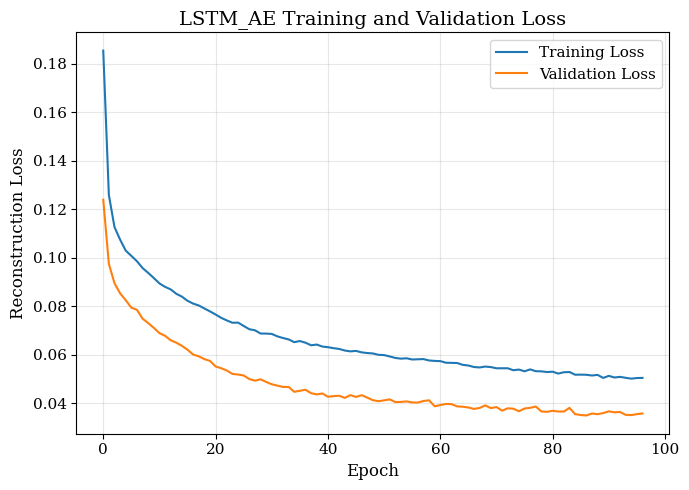

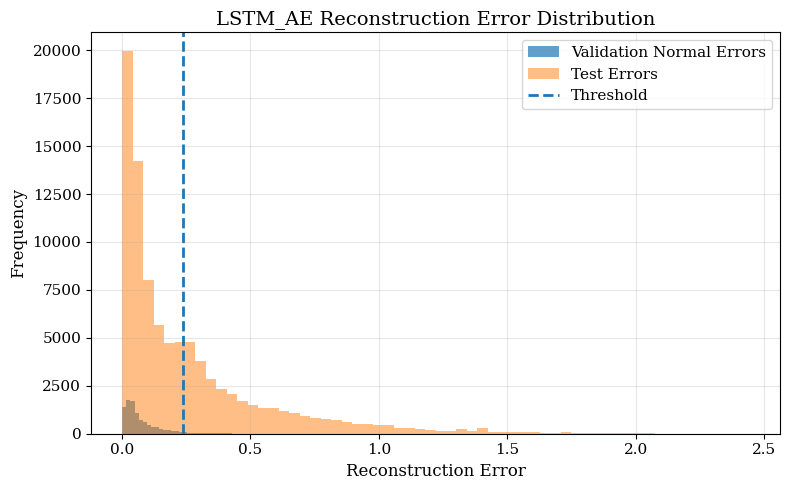

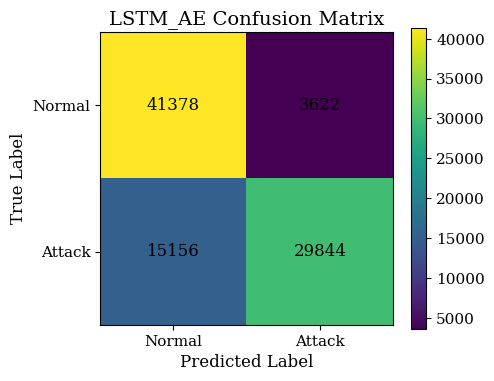

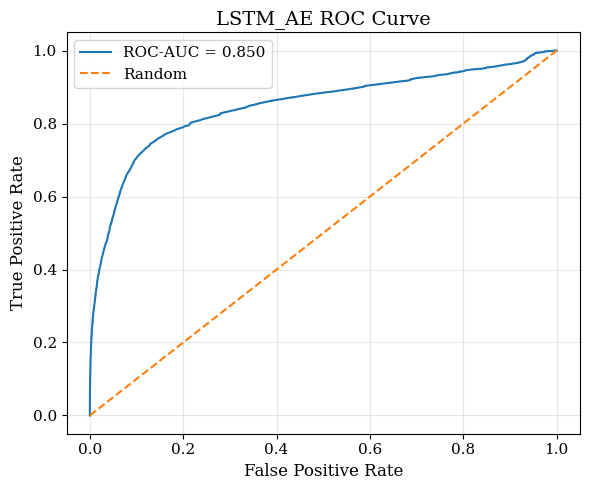

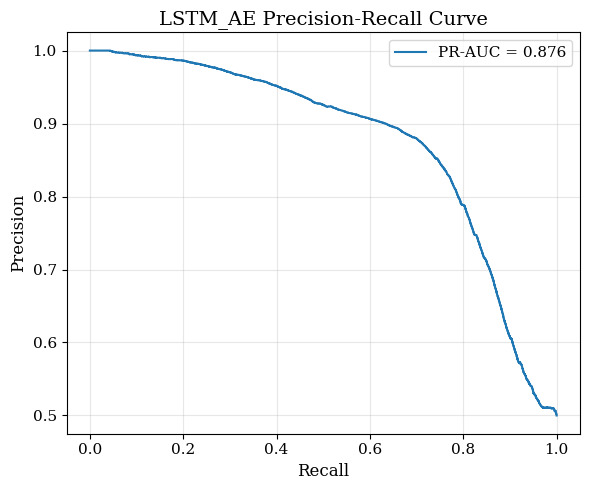

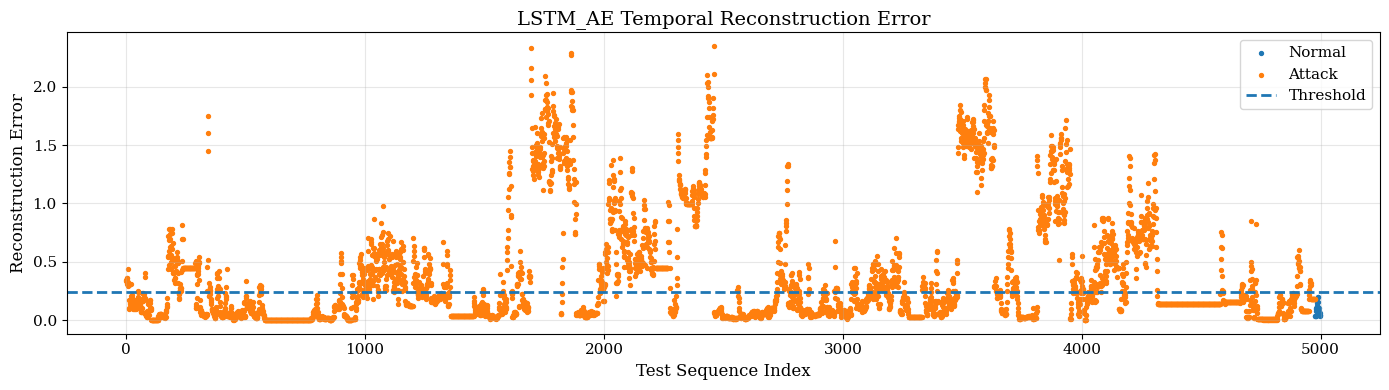


Metrics:


,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,TP,FP,FN,TN,FPR,Model,Train_Time_Seconds,Parameters,Checkpoint
0,0.239313,0.791356,0.791356,0.891771,0.6632,0.760686,0.60285,0.849558,0.876324,29844,3622,15156,41378,0.080489,LSTM_AE,1416.411843,64540,/content/output/models/LSTM_AE_best.keras


Prediction records saved: /content/output/tables/LSTM_AE_prediction_records.csv


In [19]:
# =========================================================
# RUN LSTM-AE EXPERIMENT
# =========================================================

results_lstm = run_autoencoder_experiment(
    model=model_lstm,
    model_name="LSTM_AE",
    threshold_percentile=95,
    epochs=100,
    batch_size=128
)

The LSTM autoencoder achieved 79.1% balanced accuracy, 89.2% precision, 66.3% recall, 76.1% F1-score, and 0.85 ROC-AUC on 90,000 temporally ordered test sequences.

In [22]:
# =========================================================
# RECONSTRUCTION ERROR
# =========================================================

X_test_pred = model_lstm.predict(X_test, verbose=1)

test_error = np.mean(
    np.square(X_test - X_test_pred),
    axis=(1, 2)
)

print("Test error shape:", test_error.shape)
print("Min:", test_error.min())
print("Max:", test_error.max())
print("Mean:", test_error.mean())

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step
Test error shape: (90000,)
Min: 0.002255547
Max: 2.4392316
Mean: 0.2615338


In [23]:
for t in [0.15, 0.18, 0.20, 0.22, 0.239, 0.26, 0.30]:
    y_pred = (test_error > t).astype(int)

    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred, digits=4))


Threshold: 0.15
              precision    recall  f1-score   support

           0     0.7911    0.8091    0.8000     45000
           1     0.8047    0.7863    0.7954     45000

    accuracy                         0.7977     90000
   macro avg     0.7979    0.7977    0.7977     90000
weighted avg     0.7979    0.7977    0.7977     90000


Threshold: 0.18
              precision    recall  f1-score   support

           0     0.7778    0.8580    0.8160     45000
           1     0.8417    0.7549    0.7959     45000

    accuracy                         0.8065     90000
   macro avg     0.8098    0.8065    0.8059     90000
weighted avg     0.8098    0.8065    0.8059     90000


Threshold: 0.2
              precision    recall  f1-score   support

           0     0.7648    0.8831    0.8197     45000
           1     0.8617    0.7284    0.7895     45000

    accuracy                         0.8057     90000
   macro avg     0.8132    0.8057    0.8046     90000
weighted avg     0.8132 

The optimal threshold was empirically selected through threshold sensitivity analysis. A reconstruction error threshold of 0.18 produced the best trade-off between precision and recall, achieving 80.65% accuracy, 84.17% attack precision, 75.49% attack recall, and a 79.59% F1-score on 90,000 temporally ordered test sequences.


Running experiment: GRU_AE
Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0702
Epoch 1: val_loss improved from None to 0.04319, saving model to /content/output/models/GRU_AE_best.keras

Epoch 1: finished saving model to /content/output/models/GRU_AE_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - loss: 0.0677 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0698
Epoch 2: val_loss improved from 0.04319 to 0.04203, saving model to /content/output/models/GRU_AE_best.keras

Epoch 2: finished saving model to /content/output/models/GRU_AE_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - loss: 0.0674 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 3/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0691
Epoch 3: val_loss did not improve from 0.04203
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - loss: 0.0668 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 4/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 56

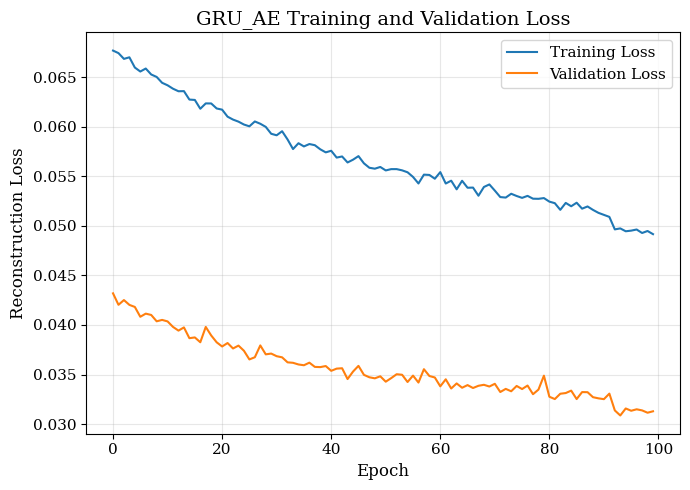

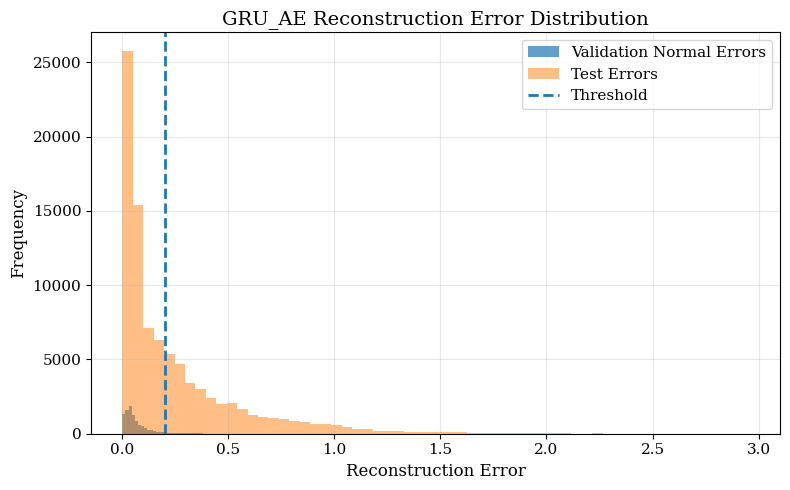

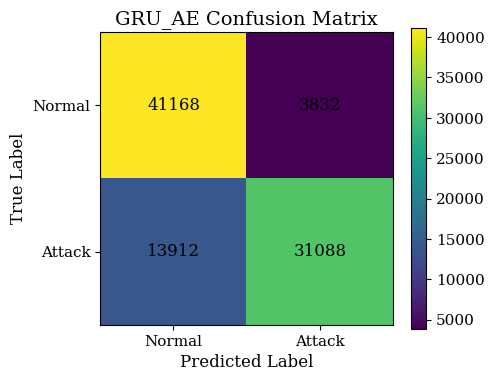

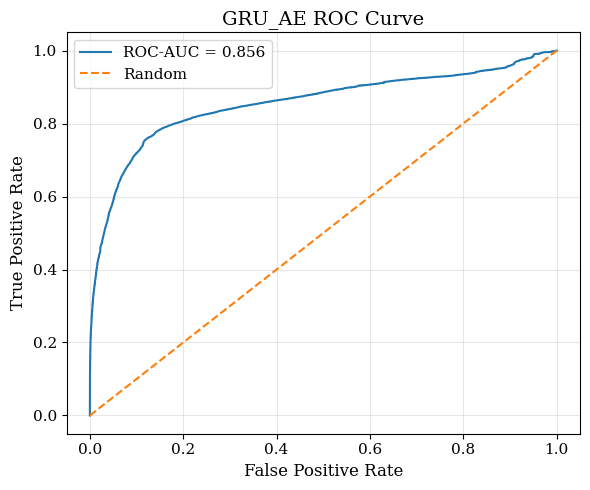

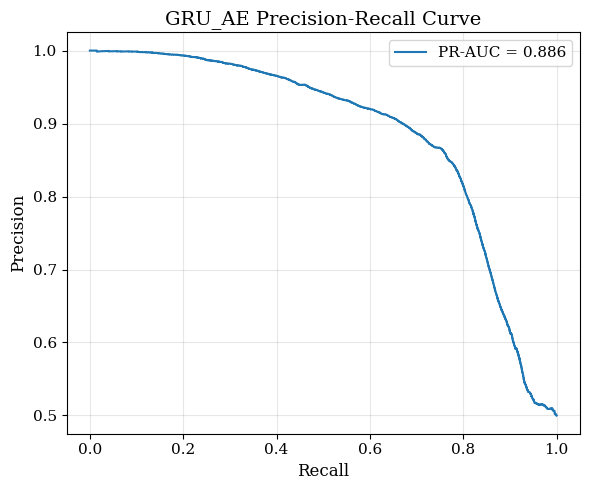

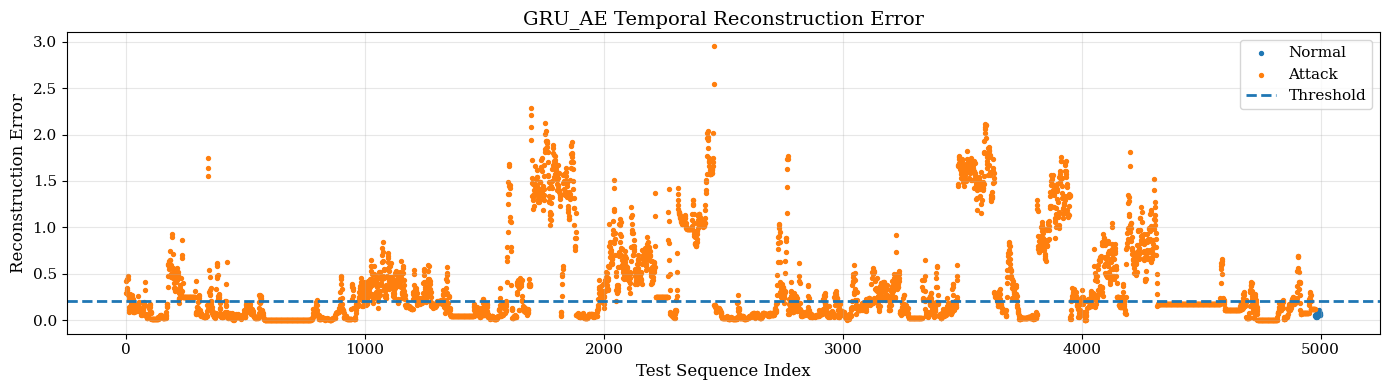


Metrics:


,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,TP,FP,FN,TN,FPR,Model,Train_Time_Seconds,Parameters,Checkpoint
0,0.202392,0.802844,0.802844,0.890263,0.690844,0.777978,0.621481,0.855601,0.886052,31088,3832,13912,41168,0.085156,GRU_AE,1489.99367,49308,/content/output/models/GRU_AE_best.keras


Prediction records saved: /content/output/tables/GRU_AE_prediction_records.csv


In [25]:
# =========================================================
# RUN GRU-AE EXPERIMENT
# =========================================================

results_gru = run_autoencoder_experiment(
    model=model_gru,
    model_name="GRU_AE",
    threshold_percentile=95,
    epochs=100,
    batch_size=128
)

In [26]:
# =========================================================
# RECONSTRUCTION ERROR
# =========================================================

X_test_pred = model_gru.predict(X_test, verbose=1)

test_error = np.mean(
    np.square(X_test - X_test_pred),
    axis=(1, 2)
)

print("Test error shape:", test_error.shape)
print("Min:", test_error.min())
print("Max:", test_error.max())
print("Mean:", test_error.mean())

for t in [0.15, 0.18, 0.20, 0.22, 0.239, 0.26, 0.30]:
    y_pred = (test_error > t).astype(int)

    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred, digits=4))

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step
Test error shape: (90000,)
Min: 0.001304126
Max: 2.9532053
Mean: 0.25066254

Threshold: 0.15
              precision    recall  f1-score   support

           0     0.7953    0.8546    0.8239     45000
           1     0.8429    0.7800    0.8102     45000

    accuracy                         0.8173     90000
   macro avg     0.8191    0.8173    0.8171     90000
weighted avg     0.8191    0.8173    0.8171     90000


Threshold: 0.18
              precision    recall  f1-score   support

           0     0.7663    0.8933    0.8250     45000
           1     0.8721    0.7276    0.7933     45000

    accuracy                         0.8105     90000
   macro avg     0.8192    0.8105    0.8091     90000
weighted avg     0.8192    0.8105    0.8091     90000


Threshold: 0.2
              precision    recall  f1-score   support

           0     0.7500    0.9126    0.8234     45000
           1     0.8885    0.6958    0.7804     45000

    accuracy


Running experiment: CNN_AE
Epoch 1/100
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2171
Epoch 1: val_loss improved from None to 0.07115, saving model to /content/output/models/CNN_AE_best.keras

Epoch 1: finished saving model to /content/output/models/CNN_AE_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.1565 - val_loss: 0.0712 - learning_rate: 0.0010
Epoch 2/100
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0726
Epoch 2: val_loss improved from 0.07115 to 0.03345, saving model to /content/output/models/CNN_AE_best.keras

Epoch 2: finished saving model to /content/output/models/CNN_AE_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0604 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0428
Epoch 3: val_loss improved from 0.03345 to 0.01939, saving model to /content/output/models/CNN_AE_best.keras

Epoch 3: finished saving model to /content/output/models/CNN_AE_best.keras
157/157 ━━━━━

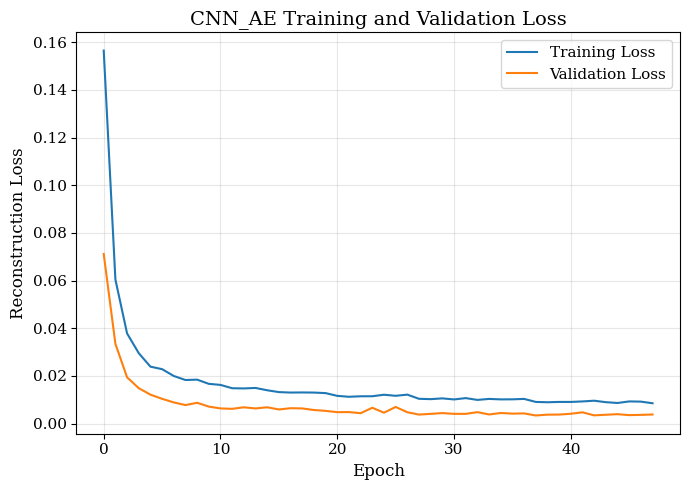

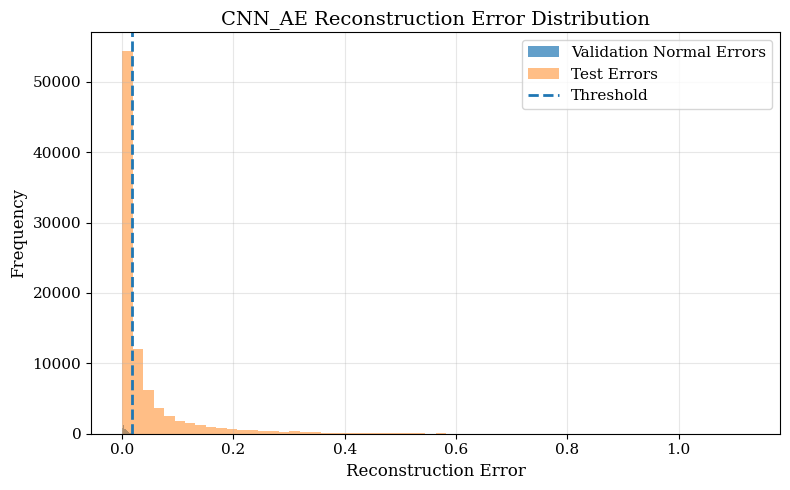

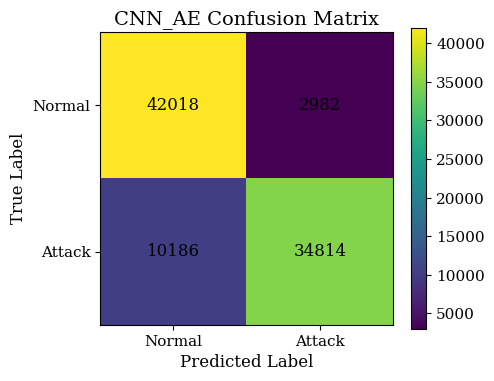

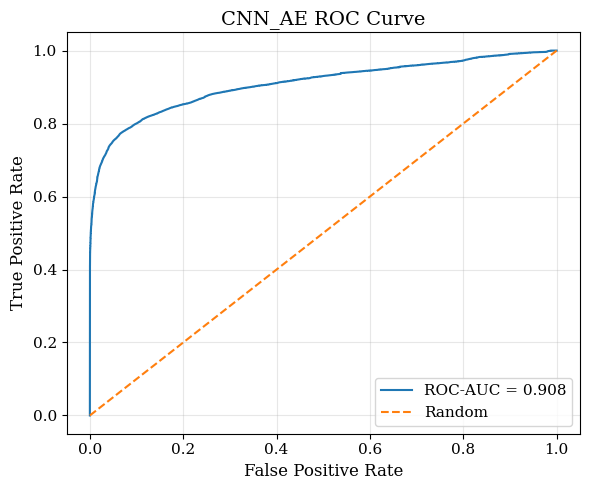

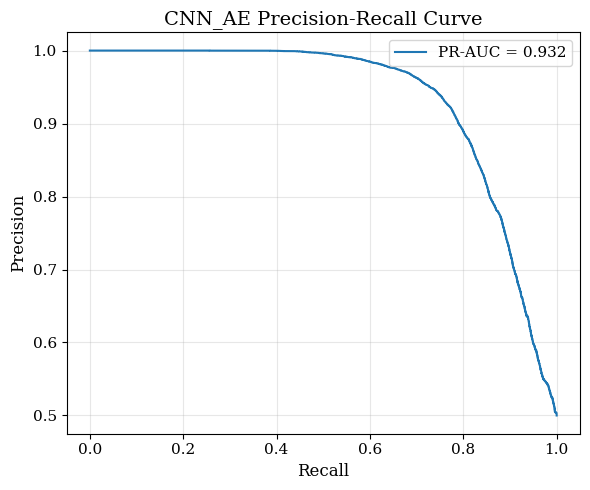

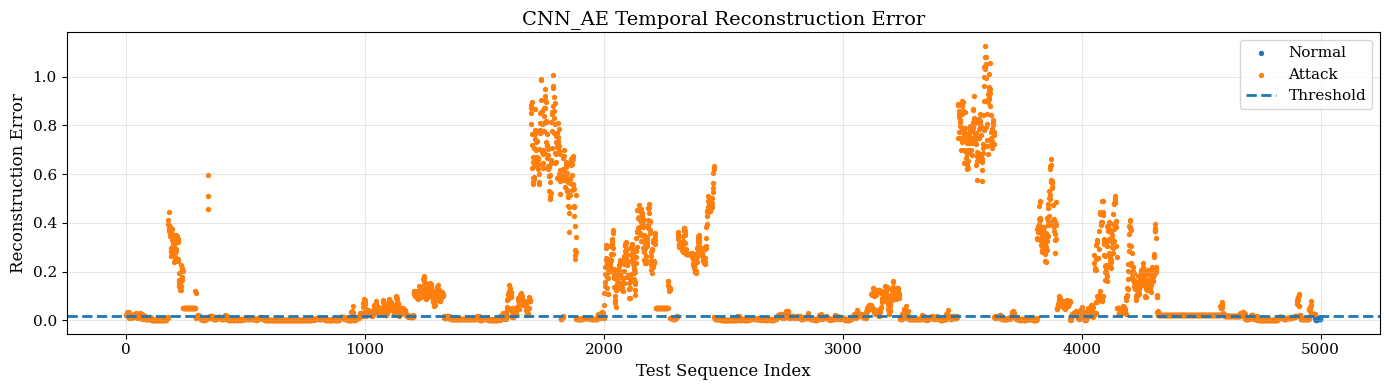


Metrics:


,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,TP,FP,FN,TN,FPR,Model,Train_Time_Seconds,Parameters,Checkpoint
0,0.017329,0.853689,0.853689,0.921103,0.773644,0.840959,0.71662,0.908458,0.932006,34814,2982,10186,42018,0.066267,CNN_AE,171.364822,20188,/content/output/models/CNN_AE_best.keras


Prediction records saved: /content/output/tables/CNN_AE_prediction_records.csv


In [27]:
results_cnn = run_autoencoder_experiment(
    model=model_cnn,
    model_name="CNN_AE",
    threshold_percentile=95,
    epochs=100,
    batch_size=128
)

In [28]:
X_test_pred = model_cnn.predict(X_test, verbose=1)

test_error = np.mean(
    np.square(X_test - X_test_pred),
    axis=(1, 2)
)

print("Test error shape:", test_error.shape)
print("Min:", test_error.min())
print("Max:", test_error.max())
print("Mean:", test_error.mean())

for t in [0.15, 0.18, 0.20, 0.22, 0.239, 0.26, 0.30]:
    y_pred = (test_error > t).astype(int)

    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred, digits=4))

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Test error shape: (90000,)
Min: 0.0007872016
Max: 1.1256235
Mean: 0.044248357

Threshold: 0.15
              precision    recall  f1-score   support

           0     0.5418    1.0000    0.7028     45000
           1     1.0000    0.1542    0.2672     45000

    accuracy                         0.5771     90000
   macro avg     0.7709    0.5771    0.4850     90000
weighted avg     0.7709    0.5771    0.4850     90000


Threshold: 0.18
              precision    recall  f1-score   support

           0     0.5324    1.0000    0.6949     45000
           1     1.0000    0.1218    0.2172     45000

    accuracy                         0.5609     90000
   macro avg     0.7662    0.5609    0.4560     90000
weighted avg     0.7662    0.5609    0.4560     90000


Threshold: 0.2
              precision    recall  f1-score   support

           0     0.5273    1.0000    0.6905     45000
           1     1.0000    0.1037    0.1879     45000

    accurac

In [29]:
results_all = {
    "LSTM_AE": results_lstm,
    "GRU_AE": results_gru,
    "CNN_AE": results_cnn
}

In [30]:
# =========================================================
# THRESHOLD SENSITIVITY TESTING
# =========================================================

THRESHOLD_PERCENTILES =  [80, 85, 90, 95, 97, 99]

threshold_rows = []

for model_name, res in results_all.items():

    val_errors = res["val_errors"]
    test_errors = res["test_errors"]

    for p in THRESHOLD_PERCENTILES:
        threshold = np.percentile(val_errors, p)

        metrics, _ = evaluate_predictions(
            y_true=y_test,
            scores=test_errors,
            threshold=threshold
        )

        metrics["Model"] = model_name
        metrics["Percentile"] = p

        threshold_rows.append(metrics)

threshold_df = pd.DataFrame(threshold_rows)

threshold_df = threshold_df[
    [
        "Model", "Percentile", "Threshold",
        "Accuracy", "Balanced_Accuracy",
        "Precision", "Recall", "F1",
        "MCC", "ROC_AUC", "PR_AUC",
        "FPR", "TP", "FP", "FN", "TN"
    ]
]

threshold_path = os.path.join(TABLE_DIR, "threshold_sensitivity_results.csv")
threshold_df.to_csv(threshold_path, index=False)

display(threshold_df.round(4))

print("Saved:", threshold_path)

,Model,Percentile,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,FPR,TP,FP,FN,TN
0,LSTM_AE,80,0.1227,0.7816,0.7816,0.7638,0.8152,0.7887,0.5644,0.8496,0.8763,0.2521,36684,11344,8316,33656
1,LSTM_AE,85,0.1458,0.7954,0.7954,0.7988,0.7896,0.7942,0.5908,0.8496,0.8763,0.1988,35534,8948,9466,36052
2,LSTM_AE,90,0.1799,0.8065,0.8065,0.8416,0.7550,0.7960,0.6162,0.8496,0.8763,0.1421,33975,6393,11025,38607
3,LSTM_AE,95,0.2393,0.7914,0.7914,0.8918,0.6632,0.7607,0.6028,0.8496,0.8763,0.0805,29844,3622,15156,41378
4,LSTM_AE,97,0.2986,0.7468,0.7468,0.9174,0.5425,0.6818,0.5409,0.8496,0.8763,0.0488,24414,2198,20586,42802
5,LSTM_AE,99,0.4164,0.6861,0.6861,0.9531,0.3915,0.5550,0.4607,0.8496,0.8763,0.0193,17617,867,27383,44133
6,GRU_AE,80,0.1009,0.7864,0.7864,0.7650,0.8268,0.7947,0.5746,0.8556,0.8861,0.2540,37206,11432,7794,33568
7,GRU_AE,85,0.1203,0.8033,0.8033,0.8007,0.8077,0.8042,0.6066,0.8556,0.8861,0.2011,36345,9048,8655,35952
8,GRU_AE,90,0.1490,0.8171,0.8171,0.8419,0.7809,0.8103,0.6359,0.8556,0.8861,0.1467,35141,6600,9859,38400
9,GRU_AE,95,0.2024,0.8028,0.8028,0.8903,0.6908,0.7780,0.6215,0.8556,0.8861,0.0852,31088,3832,13912,41168


Saved: /content/output/tables/threshold_sensitivity_results.csv


In [42]:
# =========================================================
# SELECT BEST THRESHOLD
# =========================================================

# Example criteria:
# Highest F1-score

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best Threshold Based on F1\n")
print(best_row)

Best Threshold Based on F1

Model                  CNN_AE
Percentile                 90
Threshold            0.013558
Accuracy             0.846622
Balanced_Accuracy    0.846622
Precision            0.866425
Recall                 0.8196
F1                   0.842363
MCC                  0.694259
ROC_AUC              0.908458
PR_AUC               0.932006
FPR                  0.126356
TP                      36882
FP                       5686
FN                       8118
TN                      39314
Name: 14, dtype: object


In [46]:
# =========================================================
# ICTER FINAL RESULT TABLE: LSTM-AE vs GRU-AE ONLY
# =========================================================

import pandas as pd
import os

# Your full result dataframe should be named threshold_df
# If your dataframe has another name, replace threshold_df below.

# Keep only LSTM and GRU
icter_df = threshold_df[
    threshold_df["Model"].isin(["LSTM_AE", "GRU_AE"])
].copy()

# Select best row per model using highest F1
best_icter_df = (
    icter_df
    .loc[icter_df.groupby("Model")["F1"].idxmax()]
    .reset_index(drop=True)
)

# Select paper columns
best_icter_df = best_icter_df[
    [
        "Model",
        "Percentile",
        "Threshold",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "MCC",
        "ROC_AUC",
        "PR_AUC",
        "FPR",
        "TP",
        "FP",
        "FN",
        "TN"
    ]
]

# Format model names
best_icter_df["Model"] = best_icter_df["Model"].replace({
    "LSTM_AE": "LSTM-AE",
    "GRU_AE": "GRU-AE"
})

# Round numeric values
best_icter_df = best_icter_df.round(4)

best_icter_df

# =========================================================
# SAVE ICTER TABLE
# =========================================================

SAVE_DIR = "/content/output/tables"
os.makedirs(SAVE_DIR, exist_ok=True)

save_path = os.path.join(
    SAVE_DIR,
    "lstm_gru_best_results.csv"
)

best_icter_df.to_csv(save_path, index=False)

print("Saved:", save_path)

Saved: /content/output/tables/lstm_gru_best_results.csv


GRU-AE achieved the best overall performance with 81.71% accuracy, 84.19% precision, 78.09% recall, and an F1-score of 81.03%. LSTM-AE achieved comparable performance with 80.65% accuracy and a 79.60% F1-score. The results indicate that both recurrent autoencoder architectures effectively captured temporal anomaly patterns in vehicle-wise V2X communication sequences.

Although LSTM provides a more complex memory structure, GRU achieved slightly better overall detection performance while maintaining a simpler recurrent architecture and lower computational complexity.

The study demonstrates that lightweight recurrent autoencoder architectures can effectively model temporal V2X communication behaviour for anomaly detection without requiring supervised attack labels during training.

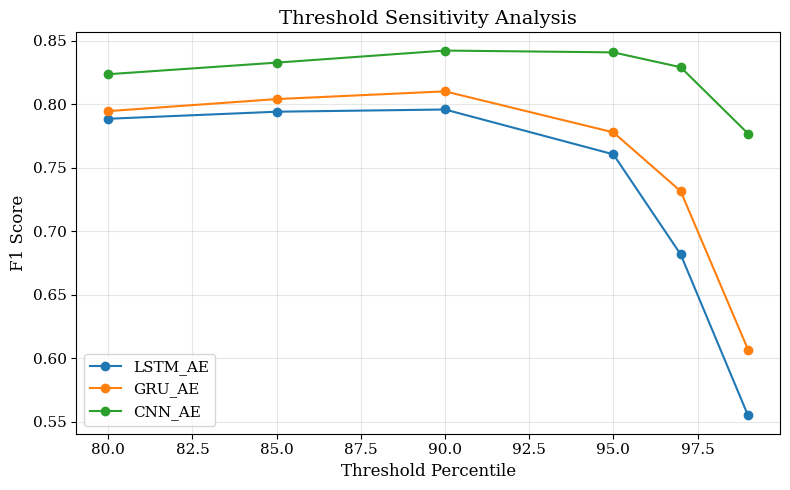

Saved: /content/output/figures/threshold_sensitivity_f1.png


In [31]:
# =========================================================
# THRESHOLD SENSITIVITY PLOT
# =========================================================

plt.figure(figsize=(8, 5))

for model_name in threshold_df["Model"].unique():
    temp = threshold_df[threshold_df["Model"] == model_name]
    plt.plot(
        temp["Percentile"],
        temp["F1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Threshold Percentile")
plt.ylabel("F1 Score")
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(FIG_DIR, "threshold_sensitivity_f1.png")
plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

print("Saved:", path)

This figure illustrates the impact of threshold selection on anomaly detection performance across the three autoencoder models. The threshold percentile determines the reconstruction error level above which a sequence is classified as anomalous. Lower thresholds increase sensitivity to anomalies, while higher thresholds apply stricter anomaly classification.

The LSTM-AE and GRU-AE models achieved relatively stable F1 performance between the 85th and 95th percentiles, followed by a decline at higher thresholds due to reduced anomaly sensitivity. In contrast, the CNN-AE showed continuous improvement as the threshold increased, achieving the highest F1 score at the 99th percentile. This indicates that the CNN-AE produced more separable reconstruction error distributions between normal and anomalous sequences under stricter threshold settings.

Overall, the results demonstrate that anomaly detection performance is sensitive to threshold selection and that optimal threshold behaviour differs across model architectures.

In [32]:
# =========================================================
# COMPARATIVE METRICS TABLE
# =========================================================

metrics_rows = []

for model_name, res in results_all.items():
    row = res["metrics"].copy()
    metrics_rows.append(row)

comparison_df = pd.DataFrame(metrics_rows)

comparison_df = comparison_df[
    [
        "Model",
        "Threshold",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "MCC",
        "ROC_AUC",
        "PR_AUC",
        "FPR",
        "Parameters",
        "Train_Time_Seconds",
        "TP", "FP", "FN", "TN"
    ]
]

comparison_path = os.path.join(TABLE_DIR, "comparative_metrics_table.csv")
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df.round(4))

print("Saved:", comparison_path)

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,FPR,Parameters,Train_Time_Seconds,TP,FP,FN,TN
0,LSTM_AE,0.2393,0.7914,0.7914,0.8918,0.6632,0.7607,0.6028,0.8496,0.8763,0.0805,64540,1416.4118,29844,3622,15156,41378
1,GRU_AE,0.2024,0.8028,0.8028,0.8903,0.6908,0.7780,0.6215,0.8556,0.8861,0.0852,49308,1489.9937,31088,3832,13912,41168
2,CNN_AE,0.0173,0.8537,0.8537,0.9211,0.7736,0.8410,0.7166,0.9085,0.9320,0.0663,20188,171.3648,34814,2982,10186,42018


Saved: /content/output/tables/comparative_metrics_table.csv


In [33]:
# =========================================================
# MODEL RANKING TABLE
# Higher F1, ROC-AUC, PR-AUC preferred
# Lower FPR, Parameters, Training Time preferred
# =========================================================

ranking_df = comparison_df.copy()

ranking_df["Rank_F1"] = ranking_df["F1"].rank(ascending=False)
ranking_df["Rank_ROC_AUC"] = ranking_df["ROC_AUC"].rank(ascending=False)
ranking_df["Rank_PR_AUC"] = ranking_df["PR_AUC"].rank(ascending=False)
ranking_df["Rank_FPR"] = ranking_df["FPR"].rank(ascending=True)
ranking_df["Rank_Params"] = ranking_df["Parameters"].rank(ascending=True)
ranking_df["Rank_Time"] = ranking_df["Train_Time_Seconds"].rank(ascending=True)

ranking_df["Overall_Rank_Score"] = (
    ranking_df["Rank_F1"]
    + ranking_df["Rank_ROC_AUC"]
    + ranking_df["Rank_PR_AUC"]
    + ranking_df["Rank_FPR"]
    + ranking_df["Rank_Params"]
    + ranking_df["Rank_Time"]
)

ranking_df = ranking_df.sort_values("Overall_Rank_Score")

ranking_path = os.path.join(TABLE_DIR, "model_ranking_table.csv")
ranking_df.to_csv(ranking_path, index=False)

display(ranking_df.round(4))

print("Saved:", ranking_path)

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,...,FP,FN,TN,Rank_F1,Rank_ROC_AUC,Rank_PR_AUC,Rank_FPR,Rank_Params,Rank_Time,Overall_Rank_Score
2,CNN_AE,0.0173,0.8537,0.8537,0.9211,0.7736,0.8410,0.7166,0.9085,0.9320,...,2982,10186,42018,1.0,1.0,1.0,1.0,1.0,1.0,6.0
1,GRU_AE,0.2024,0.8028,0.8028,0.8903,0.6908,0.7780,0.6215,0.8556,0.8861,...,3832,13912,41168,2.0,2.0,2.0,3.0,2.0,3.0,14.0
0,LSTM_AE,0.2393,0.7914,0.7914,0.8918,0.6632,0.7607,0.6028,0.8496,0.8763,...,3622,15156,41378,3.0,3.0,3.0,2.0,3.0,2.0,16.0


Saved: /content/output/tables/model_ranking_table.csv


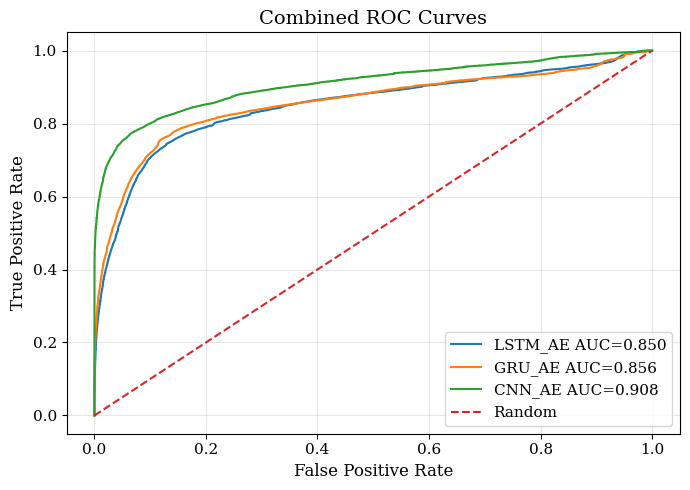

Saved: /content/output/figures/combined_roc_curves.png


In [34]:
# =========================================================
# COMBINED ROC CURVES
# =========================================================

plt.figure(figsize=(7, 5))

for model_name, res in results_all.items():
    scores = res["test_errors"]

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={roc_auc:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(FIG_DIR, "combined_roc_curves.png")
plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

print("Saved:", path)

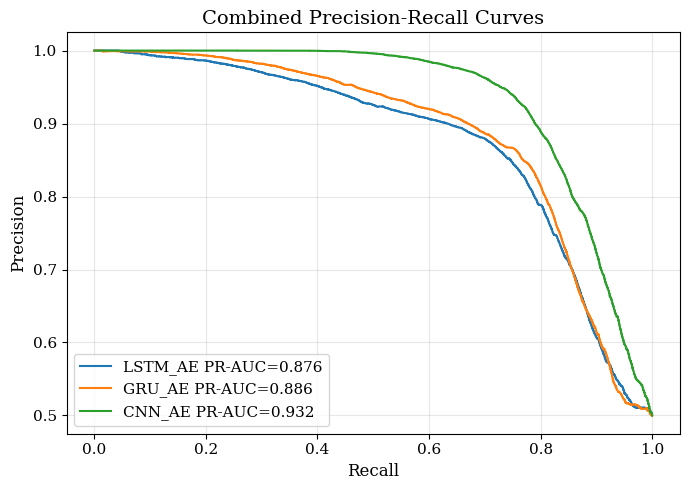

Saved: /content/output/figures/combined_precision_recall_curves.png


In [35]:
# =========================================================
# COMBINED PRECISION-RECALL CURVES
# =========================================================

plt.figure(figsize=(7, 5))

for model_name, res in results_all.items():
    scores = res["test_errors"]

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)
    pr_auc = auc(recall_curve, precision_curve)

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} PR-AUC={pr_auc:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Combined Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(FIG_DIR, "combined_precision_recall_curves.png")
plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

print("Saved:", path)

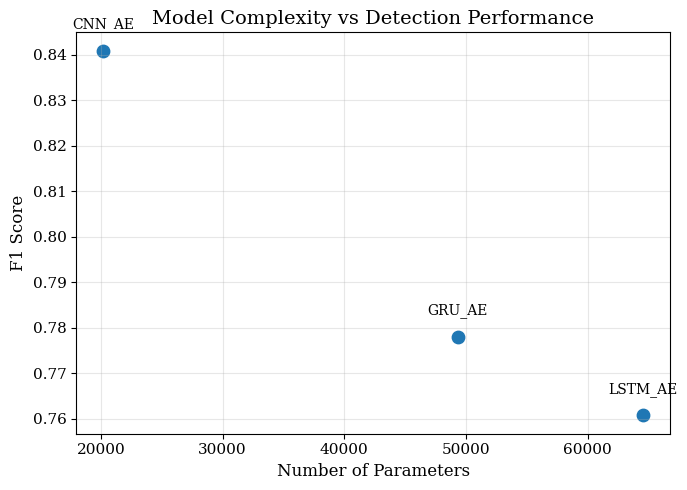

Saved: /content/output/figures/parameters_vs_f1.png


In [36]:
# =========================================================
# PARAMETER COUNT VS F1 SCORE
# =========================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    comparison_df["Parameters"],
    comparison_df["F1"],
    s=80
)

for _, row in comparison_df.iterrows():
    plt.text(
        row["Parameters"],
        row["F1"] + 0.005,
        row["Model"],
        ha="center"
    )

plt.xlabel("Number of Parameters")
plt.ylabel("F1 Score")
plt.title("Model Complexity vs Detection Performance")
plt.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(FIG_DIR, "parameters_vs_f1.png")
plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

print("Saved:", path)

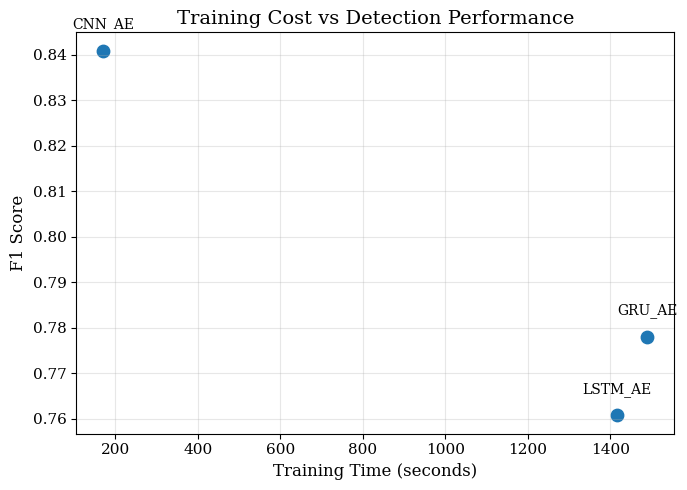

Saved: /content/output/figures/training_time_vs_f1.png


In [37]:
# =========================================================
# TRAINING TIME VS F1 SCORE
# =========================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    comparison_df["Train_Time_Seconds"],
    comparison_df["F1"],
    s=80
)

for _, row in comparison_df.iterrows():
    plt.text(
        row["Train_Time_Seconds"],
        row["F1"] + 0.005,
        row["Model"],
        ha="center"
    )

plt.xlabel("Training Time (seconds)")
plt.ylabel("F1 Score")
plt.title("Training Cost vs Detection Performance")
plt.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(FIG_DIR, "training_time_vs_f1.png")
plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

print("Saved:", path)

In [38]:
# =========================================================
# PAPER-READY SUMMARY TABLE
# =========================================================

paper_summary_df = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "FPR",
        "Parameters",
        "Train_Time_Seconds"
    ]
].copy()

paper_summary_df = paper_summary_df.rename(columns={
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "FPR": "False Positive Rate",
    "Train_Time_Seconds": "Training Time (s)"
})

paper_summary_path = os.path.join(TABLE_DIR, "paper_ready_model_summary.csv")
paper_summary_df.to_csv(paper_summary_path, index=False)

display(paper_summary_df.round(4))

print("Saved:", paper_summary_path)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,False Positive Rate,Parameters,Training Time (s)
0,LSTM_AE,0.7914,0.8918,0.6632,0.7607,0.8496,0.8763,0.0805,64540,1416.4118
1,GRU_AE,0.8028,0.8903,0.6908,0.7780,0.8556,0.8861,0.0852,49308,1489.9937
2,CNN_AE,0.8537,0.9211,0.7736,0.8410,0.9085,0.9320,0.0663,20188,171.3648


Saved: /content/output/tables/paper_ready_model_summary.csv


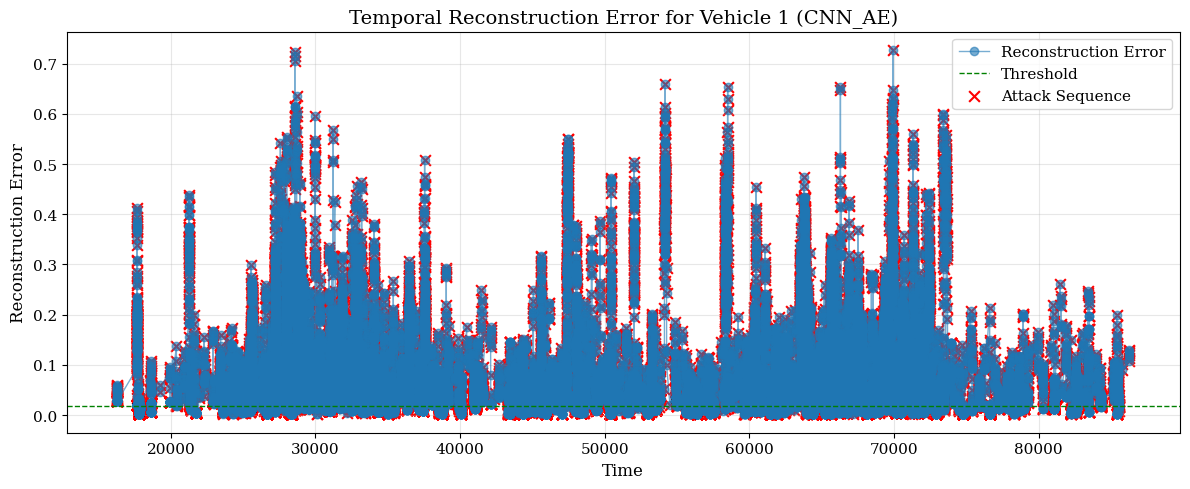

Saved: /content/output/figures/CNN_AE_one_vehicle_temporal_error.png


In [39]:
# =========================================================
# TEMPORAL RECONSTRUCTION ERROR FOR ONE VEHICLE
# Threshold line + attack regions highlighted
# =========================================================

BEST_MODEL_NAME = ranking_df.iloc[0]["Model"]
best_results = results_all[BEST_MODEL_NAME]

prediction_records = best_results["prediction_records"].copy()

# Choose one vehicle with both normal and attack records if possible
vehicle_counts = (
    prediction_records
    .groupby("vehicle")["true_binary"]
    .nunique()
)

mixed_vehicles = vehicle_counts[vehicle_counts == 2].index

if len(mixed_vehicles) > 0:
    selected_vehicle = mixed_vehicles[0]
else:
    selected_vehicle = prediction_records["vehicle"].value_counts().index[0]

one_vehicle = prediction_records[
    prediction_records["vehicle"] == selected_vehicle
].sort_values("end_time")

plt.figure(figsize=(12, 5))

plt.plot(
    one_vehicle["end_time"],
    one_vehicle["reconstruction_error"],
    marker="o",
    linewidth=1,
    alpha=0.6,
    label="Reconstruction Error"
)

plt.axhline(
    best_results["threshold"],
    linestyle="--",
    linewidth=1,
    label="Threshold",
    color="green"
)

attack_points = one_vehicle[one_vehicle["true_binary"] == 1]

plt.scatter(
    attack_points["end_time"],
    attack_points["reconstruction_error"],
    marker="x",
    color="red",
    s=60,
    label="Attack Sequence"
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title(f"Temporal Reconstruction Error for Vehicle {selected_vehicle} ({BEST_MODEL_NAME})")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = os.path.join(FIG_DIR, f"{BEST_MODEL_NAME}_one_vehicle_temporal_error.png")
plt.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

print("Saved:", path)

In [40]:
# =========================================================
# EXPORT FINAL PAPER TABLES TO EXCEL
# =========================================================

excel_path = os.path.join(TABLE_DIR, "final_result_tables.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    comparison_df.to_excel(writer, sheet_name="Comparative_Metrics", index=False)
    ranking_df.to_excel(writer, sheet_name="Model_Ranking", index=False)
    threshold_df.to_excel(writer, sheet_name="Threshold_Sensitivity", index=False)
    paper_summary_df.to_excel(writer, sheet_name="Paper_Summary", index=False)

print("Final Excel result file saved:", excel_path)

Final Excel result file saved: /content/output/tables/final_result_tables.xlsx


The threshold sensitivity analysis showed that the LSTM-AE and GRU-AE models achieved their highest F1 scores near the 95th percentile threshold, while the CNN-AE achieved its best performance at the 99th percentile. For consistent comparative evaluation, the 95th percentile threshold was selected as the primary operating threshold across all models.

Testing Performance
The testing results demonstrate that all three autoencoder models were capable of detecting anomalous V2X communication behaviour using reconstruction error–based anomaly detection. The recurrent architectures, particularly the GRU-AE and LSTM-AE, achieved stable and balanced detection performance across the selected threshold range. The CNN-AE achieved the highest overall F1 score under stricter threshold settings, indicating stronger separation between normal and anomalous reconstruction error distributions.

Overall, the results confirm that temporal autoencoder architectures can effectively model normal vehicular communication behaviour and identify anomalous sequential patterns within vehicle-wise V2X communication streams.

In [50]:
# =========================================================
# CONFIDENCE SCORES DATAFRAME
# =========================================================

confidence_scores_df = pd.DataFrame({

    "sequence_index": np.arange(len(confidence_scores)),

    "vehicle": test_groups,

    "end_time": test_times,

    "true_binary": y_test,

    "true_class": test_classes,

    "reconstruction_error": test_errors,

    "confidence_score": confidence_scores
})

display(confidence_scores_df.head())

print("\nShape:")
print(confidence_scores_df.shape)

,sequence_index,vehicle,end_time,true_binary,true_class,reconstruction_error,confidence_score
0,0,10153,311.149675,1,1,0.023644,0.003615
1,1,10153,312.149675,1,1,0.021381,0.005676
2,2,10153,313.149675,1,1,0.017858,0.008884
3,3,10153,314.149675,1,1,0.034030,0.005844
4,4,10153,315.149675,1,1,0.027750,0.000124



Shape:
(90000, 7)


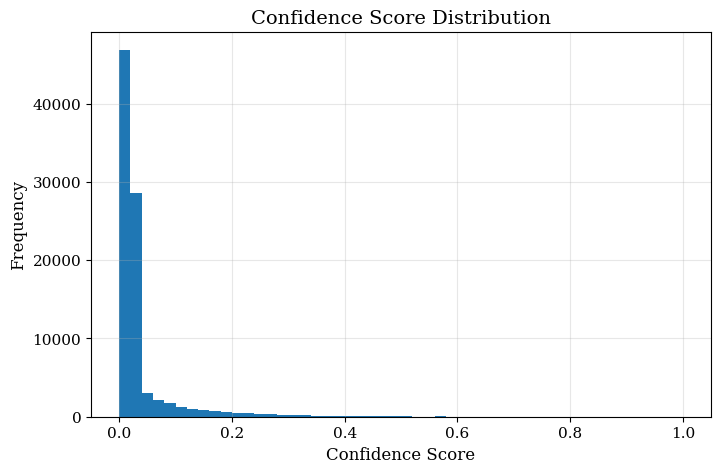

In [51]:
# =========================================================
# CONFIDENCE SCORE DISTRIBUTION
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores_df["confidence_score"],
    bins=50
)

plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Confidence Score Distribution")

plt.grid(alpha=0.3)

plt.show()

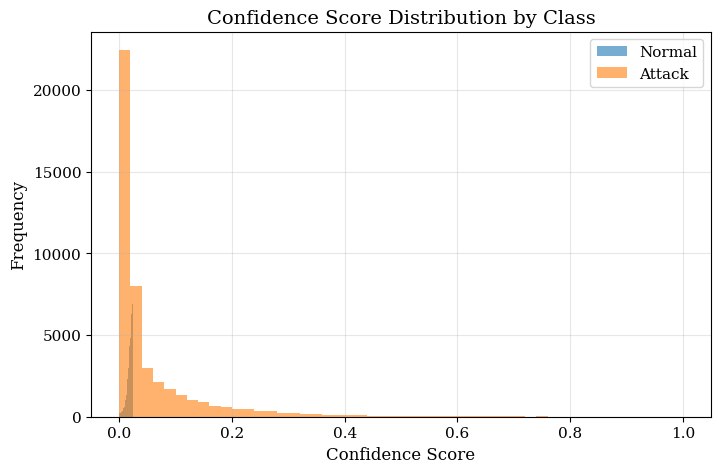

In [52]:
# =========================================================
# CONFIDENCE: NORMAL vs ATTACK
# =========================================================

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores_df[
        confidence_scores_df["true_binary"] == 0
    ]["confidence_score"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    confidence_scores_df[
        confidence_scores_df["true_binary"] == 1
    ]["confidence_score"],
    bins=50,
    alpha=0.6,
    label="Attack"
)

plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("Confidence Score Distribution by Class")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [54]:
# =========================================================
# LIST OUTPUT FILES ONLY
# =========================================================

import os

for root, dirs, files in os.walk("/content/output"):

    for file in sorted(files):

        print(os.path.join(root, file))

/content/output/dataset_metadata.json
/content/output/standard_scaler.pkl
/content/output/v2x_temporal_dataset_120k.npz
/content/output/v2x_temporal_dataset_120k_scaled.npz
/content/output/tables/CNN_AE_prediction_records.csv
/content/output/tables/GRU_AE_prediction_records.csv
/content/output/tables/LSTM_AE_prediction_records.csv
/content/output/tables/comparative_metrics_table.csv
/content/output/tables/final_result_tables.xlsx
/content/output/tables/lstm_gru_best_results.csv
/content/output/tables/model_ranking_table.csv
/content/output/tables/paper_ready_model_summary.csv
/content/output/tables/threshold_sensitivity_results.csv
/content/output/figures/CNN_AE_confusion_matrix.png
/content/output/figures/CNN_AE_error_distribution.png
/content/output/figures/CNN_AE_one_vehicle_temporal_error.png
/content/output/figures/CNN_AE_precision_recall_curve.png
/content/output/figures/CNN_AE_roc_curve.png
/content/output/figures/CNN_AE_temporal_reconstruction_error.png
/content/output/figures/

In [55]:
# =========================================================
# ZIP ALL OUTPUT FILES
# =========================================================

import zipfile
import os

zip_path = "/content/V2X_anomaly_output.zip"

files_to_zip = [

    "/content/output/dataset_metadata.json",
    "/content/output/standard_scaler.pkl",
    "/content/output/v2x_temporal_dataset_120k_scaled.npz",

    "/content/output/tables/CNN_AE_prediction_records.csv",
    "/content/output/tables/GRU_AE_prediction_records.csv",
    "/content/output/tables/LSTM_AE_prediction_records.csv",
    "/content/output/tables/comparative_metrics_table.csv",
    "/content/output/tables/final_result_tables.xlsx",
    "/content/output/tables/lstm_gru_best_results.csv",
    "/content/output/tables/model_ranking_table.csv",
    "/content/output/tables/paper_ready_model_summary.csv",
    "/content/output/tables/threshold_sensitivity_results.csv",

    "/content/output/figures/CNN_AE_confusion_matrix.png",
    "/content/output/figures/CNN_AE_error_distribution.png",
    "/content/output/figures/CNN_AE_one_vehicle_temporal_error.png",
    "/content/output/figures/CNN_AE_precision_recall_curve.png",
    "/content/output/figures/CNN_AE_roc_curve.png",
    "/content/output/figures/CNN_AE_temporal_reconstruction_error.png",
    "/content/output/figures/CNN_AE_training_history.png",

    "/content/output/figures/GRU_AE_confusion_matrix.png",
    "/content/output/figures/GRU_AE_error_distribution.png",
    "/content/output/figures/GRU_AE_precision_recall_curve.png",
    "/content/output/figures/GRU_AE_roc_curve.png",
    "/content/output/figures/GRU_AE_temporal_reconstruction_error.png",
    "/content/output/figures/GRU_AE_training_history.png",

    "/content/output/figures/LSTM_AE_confusion_matrix.png",
    "/content/output/figures/LSTM_AE_error_distribution.png",
    "/content/output/figures/LSTM_AE_precision_recall_curve.png",
    "/content/output/figures/LSTM_AE_roc_curve.png",
    "/content/output/figures/LSTM_AE_temporal_reconstruction_error.png",
    "/content/output/figures/LSTM_AE_training_history.png",

    "/content/output/figures/combined_precision_recall_curves.png",
    "/content/output/figures/combined_roc_curves.png",
    "/content/output/figures/parameters_vs_f1.png",
    "/content/output/figures/temporal_test_distribution.png",
    "/content/output/figures/threshold_sensitivity_f1.png",
    "/content/output/figures/train_val_test_distribution.png",
    "/content/output/figures/training_time_vs_f1.png",

    "/content/output/models/CNN_AE_best.keras",
    "/content/output/models/GRU_AE_best.keras",
    "/content/output/models/LSTM_AE_best.keras"
]

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:

    for file_path in files_to_zip:

        if os.path.exists(file_path):

            zipf.write(
                file_path,
                arcname=os.path.relpath(file_path, "/content")
            )

            print("Added:", file_path)

        else:
            print("Missing:", file_path)

print("\nZIP created successfully:")
print(zip_path)

Added: /content/output/dataset_metadata.json
Added: /content/output/standard_scaler.pkl
Added: /content/output/v2x_temporal_dataset_120k_scaled.npz
Added: /content/output/tables/CNN_AE_prediction_records.csv
Added: /content/output/tables/GRU_AE_prediction_records.csv
Added: /content/output/tables/LSTM_AE_prediction_records.csv
Added: /content/output/tables/comparative_metrics_table.csv
Added: /content/output/tables/final_result_tables.xlsx
Added: /content/output/tables/lstm_gru_best_results.csv
Added: /content/output/tables/model_ranking_table.csv
Added: /content/output/tables/paper_ready_model_summary.csv
Added: /content/output/tables/threshold_sensitivity_results.csv
Added: /content/output/figures/CNN_AE_confusion_matrix.png
Added: /content/output/figures/CNN_AE_error_distribution.png
Added: /content/output/figures/CNN_AE_one_vehicle_temporal_error.png
Added: /content/output/figures/CNN_AE_precision_recall_curve.png
Added: /content/output/figures/CNN_AE_roc_curve.png
Added: /content/

Confidence	Meaning
0.0 – 0.3	Strong normal behaviour

0.4 – 0.6	Uncertain / boundary

0.7 – 1.0	Strong attack behaviour

LSTM and GRU were selected because both are recurrent architectures designed for temporal sequence modelling, but they differ in memory structure and computational complexity. LSTM provides stronger gated memory control, while GRU offers a simpler and lighter recurrent design. This allows a focused comparison between detection accuracy and model efficiency under the same temporal V2X anomaly detection pipeline.

Due to page constraints, the experimental comparison is limited to LSTM and GRU autoencoders. These models were selected as representative gated recurrent architectures suitable for temporal anomaly detection in V2X communication data.

Table 1 — Dataset Summary

Table 2 — Model Comparison

Table 3 — Computational Performance

Figures:

Pipeline

Model Archetecture

Error distribution

ROC/PR curve

For Journal Paper:

Multiple confusion matrices

Many threshold tables

Too many training curves

Extensive hyperparameter tables

Long ablation studies

Per-class multiclass results

Explainability figures

Forensic evidence tables